In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a DataFrame representing the six possible outcomes of rolling a die
# Each row contains one face value from 1 to 6
die = pd.DataFrame([1, 2, 3, 4, 5, 6])

# Define the number of times (trials) we want to simulate the dice game
trial = 50

# Simulate rolling two dice 50 times
# die.sample(2, replace=True) randomly selects 2 values from the die DataFrame
# replace=True allows the same value to be selected more than once,
# which mimics rolling two independent dice
# .sum() adds the two selected values together
# .loc[0] extracts the sum value from the resulting Series
# The list comprehension repeats this process 50 times and stores the results in a list
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

In [3]:
# Count how many times each sum appears in the simulation results
# pd.DataFrame(results)[0] converts the list of results into a DataFrame
# and selects the first (and only) column containing the sums
# .value_counts() counts the frequency of each unique sum
freq = pd.DataFrame(results)[0].value_counts()

# Sort the frequencies by the sum values (index) in ascending order
# This makes it easier to see the distribution from the smallest sum (2)
# to the largest sum (12)
sort_freq = freq.sort_index()

# Display the frequency table
# The output shows each possible sum and the number of times it occurred
print(sort_freq)

0
2      3
3      3
4      3
5      6
6      8
7      7
8     11
9      4
10     1
11     2
12     2
Name: count, dtype: int64


<Axes: xlabel='0'>

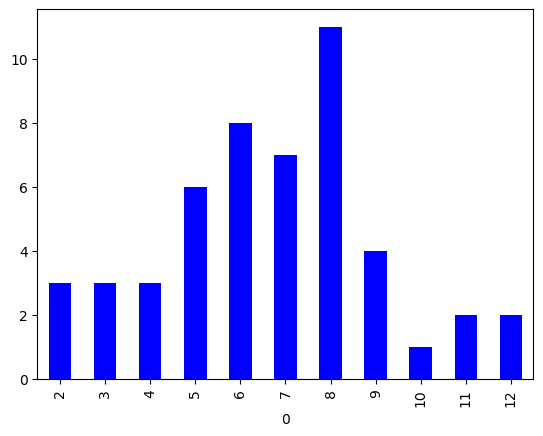

In [4]:
#plot the bar chart base on the result

sort_freq.plot(kind='bar', color='blue')

In [ ]:
# Relative Frequency

<Axes: xlabel='0'>

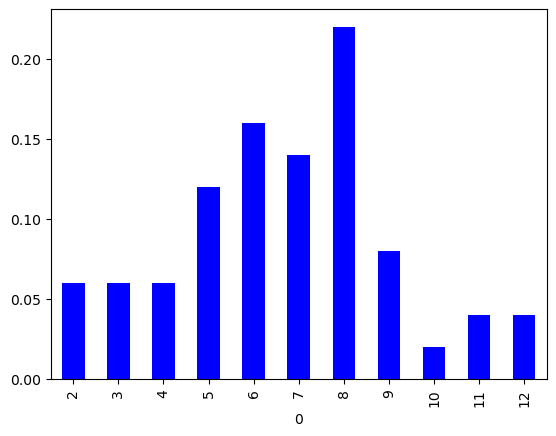

In [5]:
# Using relative frequency, we can rescale the frequency so that we can compare results from different number of trials
relative_freq = sort_freq/trial
relative_freq.plot(kind='bar', color='blue')

<Axes: xlabel='0'>

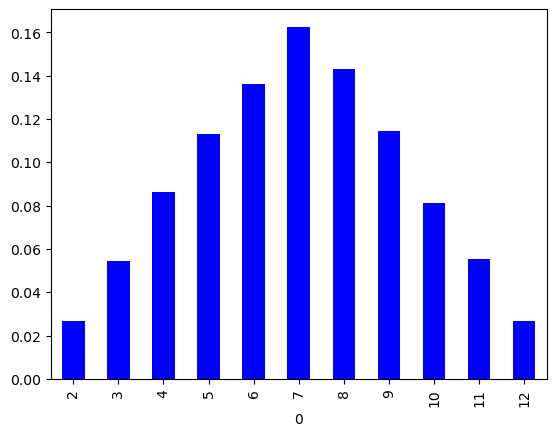

In [6]:
# Set number of simulation trials (we are increasing from a small number to a large one)
# This helps us see how results behave when we repeat the experiment many times
trial = 10000

# Simulate rolling two dice repeatedly (10000 times)
# die.sample(2, replace=True) → randomly picks 2 values from the die (with repetition allowed)
# .sum() → adds the two values together to get the total for each roll
# .loc[0] → extracts the numeric result from the resulting Series
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

# Convert results list into a DataFrame and count how often each sum appears
# value_counts() → gives frequency of each possible sum (e.g., 2 to 12 for two dice)
freq = pd.DataFrame(results)[0].value_counts()

# Sort the frequency by the dice sum (so bars appear in logical order: 2,3,4,...)
sort_freq = freq.sort_index()

# Convert absolute frequency into relative frequency (probability estimate)
# This shows proportions instead of raw counts
relative_freq = sort_freq / trial

# Plot a bar chart of the relative frequencies
# kind='bar' → creates a bar chart
# color='blue' → sets bar color to blue
relative_freq.plot(kind='bar', color='blue')

In [ ]:
# Expectations and Variance of a Distribution

In [7]:
# We assume the dice are fair, meaning each face (1–6) has equal probability

# Create a DataFrame to represent all possible sums of two dice
# The possible sums range from 2 to 12, so we set them as the index
X_distri = pd.DataFrame(index=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

# Manually assign the number of ways each sum can occur when rolling two dice
# For example:
# 2 → (1,1) = 1 way
# 3 → (1,2), (2,1) = 2 ways
# ...
# 7 → most common = 6 ways
X_distri['Prob'] = [1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1]

# Convert number of favorable outcomes into actual probabilities
# Total possible outcomes when rolling two dice = 6 * 6 = 36
X_distri['Prob'] = X_distri['Prob'] / 36

# Display the probability distribution table
X_distri

,Prob
2,0.027778
3,0.055556
4,0.083333
5,0.111111
6,0.138889
7,0.166667
8,0.138889
9,0.111111
10,0.083333
11,0.055556


In [8]:
# Compute the expected value (mean) of the distribution of sum of two dice

# X_distri.index contains possible outcomes: [2, 3, 4, ..., 12]
# X_distri['Prob'] contains probability of each outcome

# Multiply each outcome by its probability and sum everything
# This follows the formula: E(X) = Σ [x * P(x)]
mean = pd.Series(X_distri.index * X_distri['Prob']).sum()


# Compute the variance of the distribution

# Step 1: (X - mean)^2 gives squared distance from the mean
# Step 2: multiply by probability of each outcome
# Step 3: sum everything to apply: Var(X) = Σ [(x - μ)^2 * P(x)]
var = pd.Series(((X_distri.index - mean) ** 2) * X_distri['Prob']).sum()

In [9]:
# Print the mean and variance of the distribution

# mean → expected average value of the sum of two dice (should be around 7)
# var → measures how spread out the possible sums are around the mean

print(mean, var)

6.999999999999998 5.833333333333333


In [ ]:
# Empirical Mean and Variance

In [10]:
# We increase the number of trials to 20,000
# This gives a more accurate approximation of the true distribution (Law of Large Numbers)
trial = 20000

# Simulate rolling two dice 20,000 times
# Each iteration:
# - randomly sample 2 values from the die (with replacement)
# - sum them to get the result of one dice roll pair
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

In [11]:
# Convert the list of simulation results into a pandas Series
# This makes it easier to compute statistical measures like mean and variance
results = pd.Series(results)

# Compute and print the sample mean and sample variance from the simulation
# mean() → average of all simulated dice sums
# var() → variance (spread) of the simulated results
print(results.mean(), results.var())

6.9815 5.897152607630241


In [ ]:
# Models of Stock Return

In [14]:
# Load the Microsoft stock data from a CSV file into a pandas DataFrame
ms = pd.read_csv('data/microsoft.csv', index_col='Date')
# Display the first 5 rows of the Microsoft stock dataset
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


In [ ]:
# Distribution of Log Return

In [15]:
# Calculate the daily log return of Microsoft's stock price

# Create a new column called 'LogReturn' in the Microsoft DataFrame
ms['LogReturn'] = np.log(ms['Close']).shift(-1) - np.log(ms['Close'])

# np.log(ms['Close']) → calculates the natural logarithm of each closing price
# 
# .shift(-1) → moves the next day's closing price up so we can compare:
# today's price with tomorrow's price
#
# The calculation:
# log(Tomorrow's Close) - log(Today's Close)
# gives the log daily return


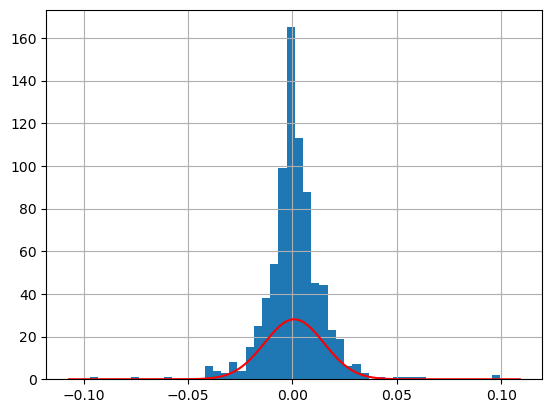

In [16]:
# Plot a histogram to show the distribution of log return of Microsoft's stock. 
# You can see it is very close to a normal distribution
from scipy.stats import norm
mu = ms['LogReturn'].mean()
sigma = ms['LogReturn'].std(ddof=1)

density = pd.DataFrame()
density['x'] = np.arange(ms['LogReturn'].min()-0.01, ms['LogReturn'].max()+0.01, 0.001)
density['pdf'] = norm.pdf(density['x'], mu, sigma)

ms['LogReturn'].hist(bins=50)
plt.plot(density['x'], density['pdf'], color='red')
plt.show()

In [ ]:
# Calculate the probability of the stock price will drop over a certain percentage in a day

In [17]:
# Calculate the probability that Microsoft's stock price will drop by more than 5% in one day

# norm.cdf() calculates the cumulative probability from a normal distribution
# It gives the probability that a value is less than or equal to a given point
#
# -0.05 represents a -5% log return (a drop of more than 5%)
# mu represents the average daily log return (mean)
# sigma represents the standard deviation of daily log returns (volatility)

prob_return1 = norm.cdf(-0.05, mu, sigma)

# Display the probability of Microsoft having a daily return below -5%
print('The Probability is ', prob_return1)

The Probability is  0.00017118482608677817


In [18]:
# Calculate the probability that Microsoft's stock price will drop by more than 10% in one day

# norm.cdf() calculates the cumulative probability under a normal distribution
# It tells us the probability that the daily log return is less than or equal to a specific value
#
# -0.10 represents a 10% negative log return (a 10% drop)
# mu represents the average daily log return
# sigma represents the standard deviation (volatility) of daily log returns

prob_return1 = norm.cdf(-0.10, mu, sigma)

# Print the probability of Microsoft experiencing a daily loss greater than 10%
print('The Probability is ', prob_return1)

The Probability is  6.056775634858521e-13


In [ ]:
# Calculate the probability of the stock price will drop over a certain percentage in a year

In [19]:
# Estimate the probability that Microsoft's stock price will drop by more than 40% over 220 trading days

# Calculate the expected (average) return over 220 days
# Since daily returns are assumed to be independent,
# the expected return scales linearly with the number of days
mu220 = 220 * mu

# Calculate the standard deviation (volatility) over 220 days
# Volatility scales with the square root of time
# This follows the rule: new_sigma = sqrt(number_of_days) * daily_sigma
sigma220 = (220 ** 0.5) * sigma

# Calculate and print the probability of a loss greater than 40% over 220 days
# -0.4 represents a 40% negative return
# norm.cdf() gives the probability that the return is below this threshold
print('The probability of dropping over 40% in 220 days is ', 
      norm.cdf(-0.4, mu220, sigma220))

The probability of dropping over 40% in 220 days is  0.002912363313330548


In [20]:
# Estimate probability that Microsoft stock drops more than 20% over 220 trading days

# Scale the mean return to 220 days
# Assumption: daily returns are independent, so mean scales linearly
mu220 = 220 * mu

# Scale volatility to 220 days
# Risk increases with square root of time, not linearly
sigma220 = (220 ** 0.5) * sigma

# Compute probability that cumulative return is less than -20%
# -0.20 represents a 20% loss threshold
# norm.cdf() gives probability of being below that threshold
drop20 = norm.cdf(-0.20, mu220, sigma220)

# Print the result
print('The probability of dropping over 20% in 220 days is ', drop20)

The probability of dropping over 20% in 220 days is  0.03535237727490905


In [ ]:
# Calculate Value at risk (VaR)

In [21]:
# Value at Risk (VaR) calculation for a single day

# norm.ppf() is the inverse of norm.cdf()
# It returns the value (return level) below which a given percentage of observations fall

# 0.05 means we are looking at the worst 5% of outcomes
# mu is the mean daily return
# sigma is the standard deviation (volatility)

VaR = norm.ppf(0.05, mu, sigma)

# Print the Value at Risk
print('Single day value at risk ', VaR)

Single day value at risk  -0.022523362407065


In [22]:
# Quantiles divide a probability distribution into intervals

# norm.ppf() is the inverse of the cumulative distribution function (CDF)
# It gives the value of x such that a given percentage of observations fall below it

# 5% quantile (lower tail)
# This is the value below which 5% of daily returns are expected to fall
print('5% quantile ', norm.ppf(0.05, mu, sigma))

# 95% quantile (upper tail)
# This is the value below which 95% of daily returns are expected to fall
# In other words, only 5% of returns are above this value
print('95% quantile ', norm.ppf(0.95, mu, sigma))

5% quantile  -0.022523362407065
95% quantile  0.024163825379311034


In [23]:
# Calculate the 25% and 75% quantiles of the return distribution

# norm.ppf() gives the value below which a certain percentage of data falls

# 25% quantile (first quartile, Q1)
# This is the return value below which 25% of daily returns fall
q25 = norm.ppf(0.25, mu, sigma)
print('25% quantile ', q25)

# 75% quantile (third quartile, Q3)
# This is the return value below which 75% of daily returns fall
# Meaning: only 25% of returns are above this value
q75 = norm.ppf(0.75, mu, sigma)
print('75% quantile ', q75)

25% quantile  -0.008752057838414963
75% quantile  0.010392520810661006


In [ ]:
# Outcomes and Variables
# Mimic the Roll Dice Game

In [24]:
# Create a DataFrame representing a fair die with values 1 to 6
die = pd.DataFrame([1, 2, 3, 4, 5, 6])

# Simulate rolling two dice once
# sample(2, replace=True) → randomly pick 2 values (like rolling 2 dice)
# replace=True → allows the same number to appear on both dice
# .sum() → adds the two dice values together
# .loc[0] → extracts the numeric result from the Series
sum_of_dice = die.sample(2, replace=True).sum().loc[0]

# Print the result of the single dice roll
print('Sum of dice is', sum_of_dice)

# Note:
# The result will always be between 2 and 12 because:
# - Minimum: 1 + 1 = 2
# - Maximum: 6 + 6 = 12

Sum of dice is 10


In [25]:
# Set random seed for reproducibility
# This ensures everyone gets the same “random” result when running the code
np.random.seed(1)

# Roll three dice instead of two
# sample(3, replace=True) → randomly picks 3 values from the die (1–6)
# replace=True → same number can appear multiple times
# sum() → adds the three dice values together
# loc[0] → extracts the final numeric result from the pandas Series

sum_of_three_dice = die.sample(3, replace=True).sum().loc[0]

In [26]:
# Print the result of rolling three dice once
print('Sum of three dice is', sum_of_three_dice)

Sum of three dice is 15


In [ ]:
# Mimic the roll dice game for multiple times

In [27]:
# Set the number of simulations (how many times we roll the dice)
trial = 50

# Simulate rolling two dice 50 times
# Each iteration:
# - die.sample(2, replace=True) → randomly selects 2 values (like rolling 2 dice)
# - .sum() → adds the two dice values
# - .loc[0] → extracts the numeric result
#
# The loop repeats this process 50 times and stores all results in a list
result = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

In [28]:
#print the first 10 results
print(result[:10])

[np.int64(3), np.int64(10), np.int64(2), np.int64(7), np.int64(11), np.int64(5), np.int64(11), np.int64(8), np.int64(9), np.int64(8)]
